# Monolayer Lift-Off: 3D Polyhedral Cells with Boundary Apical Tension

This notebook builds a **3D monolayer** epithelium by extruding the flat
`test_square.hf5` sheet, then runs a vertex-model simulation through the
`EulerSolver` process (same `process-bigraph` wiring used in `tests/tests.py`
and `Demo.ipynb`).

**Energy model.** Each polyhedral cell carries:
- **Cell volume elasticity** — $K_V (V - V_0)^2$, resists volume change.
- **Face area elasticity** — $K_A (A - A_0)^2$ on every (apical / basal / lateral) face.
- **Face contractility** — $K_P\,P^2$, an actomyosin-like perimeter term.
- **Line tension** — $\Lambda\, \ell$ on edges. We set a **higher line tension on
  the apical edges at the boundary of the tissue** (the free perimeter of the
  apical surface). This purse-string-like tension is the experimental knob:
  it should pull the rim and test whether the sheet **lifts off** the z = 0 plane
  it started flat on.

Everything below the *Parameters* cell is plain data — tweak the scalars, the
effector list, and the spec, then run the composite.

In [1]:
import sys, os
# Make the project package importable no matter where Jupyter was launched from.
_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

import warnings
warnings.filterwarnings("ignore")  # silence pandas-3 / tyssue chatter

import numpy as np
import pandas as pd
from pprint import pprint

from bigraph_schema import allocate_core
from process_bigraph import Composite
from process_bigraph.emitter import emitter_from_wires, gather_emitter_results
from bigraph_viz import plot_bigraph

from tyssue import Monolayer, Sheet, config as tyssue_config
from tyssue.io.hdf5 import load_datasets, save_datasets
from tyssue.geometry.bulk_geometry import MonolayerGeometry

from vivarium_tyssue.data_types import register_types
from vivarium_tyssue.processes import register_processes
from vivarium_tyssue.processes.eulersolver import EulerSolver

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)
from IPython.display import display

## 1. Extrude the flat sheet into a 3D monolayer

We load `test_square.hf5` (a flat `Sheet`, apical surface at z = 0) and extrude it
**downward by `THICKNESS = 1`** with `Monolayer.from_flat_sheet`. This creates one
polyhedral cell per original face, each with an **apical** face (top, z = 0), a
**basal** face (bottom, z = −1) and **lateral** side walls. The result is written to
a new HDF5 file in this directory that the `EulerSolver` will load.

In [2]:
SOURCE_SHEET   = "test_square.hf5"      # flat input sheet (this directory)
MONOLAYER_FILE = "monolayer_box.hf5"    # extruded 3D output written here
THICKNESS      = 1.0                     # extrusion height (apical->basal)

# Build the monolayer from the flat sheet.
_sheet = Sheet("square", load_datasets(SOURCE_SHEET))
mono = Monolayer.from_flat_sheet("monolayer", _sheet,
                                 tyssue_config.geometry.bulk_spec(),
                                 thickness=THICKNESS)
MonolayerGeometry.update_all(mono)

# Persist the 3D tissue so EulerSolver can load it by name.
save_datasets(MONOLAYER_FILE, mono)

print(f"wrote {MONOLAYER_FILE}")
print(f"cells={mono.Nc}  faces={mono.Nf}  verts={mono.Nv}  edges={mono.Ne}")
print("face segments:", list(mono.face_df['segment'].unique()))
print(f"apical z = {mono.vert_df.query('segment==\"apical\"').z.mean():.2f}, "
      f"basal z = {mono.vert_df.query('segment==\"basal\"').z.mean():.2f}")

C++ extensions are not available for this version
wrote monolayer_box.hf5
cells=206  faces=1590  verts=820  edges=7068
face segments: ['apical', 'basal', 'lateral']
apical z = 0.00, basal z = -1.00


## 2. Identify the boundary apical edges

The apical faces form a 2-D sheet on top of the monolayer. Its **free perimeter
edges have no opposite half-edge** (`opposite == -1`). Those are exactly the
"apical face edges at the boundary of the tissue" we want to put extra tension
on. We build a boolean mask over the monolayer's full edge table; the edge order
matches the saved file, so the per-edge `line_tension` list we derive from it
lines up with what `EulerSolver` loads.

In [3]:
edge_df = mono.edge_df
boundary_apical_mask = ((edge_df["segment"] == "apical") &
                        (edge_df["opposite"] == -1)).values
apical_mask = (edge_df["segment"] == "apical").values
print(f"{boundary_apical_mask.sum()} boundary apical edges "
      f"out of {len(edge_df)} total edges")

52 boundary apical edges out of 7068 total edges


## 3. Parameters — **tweak here**

Every knob for the simulation lives in this cell. Change values, re-run from here
down. `line_tension` is assembled as a per-edge array so the boundary apical
edges get `BOUNDARY_APICAL_TENSION` while everything else gets `BULK_LINE_TENSION`.

In [4]:
# --- mechanics ---------------------------------------------------------------
VOL_ELASTICITY    = 1.0    # K_V  : cell volume stiffness
PREFERRED_VOL     = 1.0    # V_0  : target cell volume (~area*thickness for the box)
AREA_ELASTICITY   = 1.0    # K_A  : face area stiffness (all faces)
PREFERRED_AREA    = 1.0    # A_0  : target face area
CONTRACTILITY     = 0.05   # K_P  : face (perimeter) contractility
VISCOSITY         = 1.0    # vertex drag (sets the relaxation timescale)

# --- the experimental knob ---------------------------------------------------
BULK_LINE_TENSION        = 0.0   # line tension on ordinary edges
BOUNDARY_APICAL_TENSION  = 1.0   # >> bulk: purse-string on the apical rim

# --- effectors / model -------------------------------------------------------
EFFECTORS  = ["CellVolumeElasticity", "FaceAreaElasticity",
              "FaceContractility", "LineTension"]
REF_EFFECTOR = "FaceAreaElasticity"   # used by the factory to non-dimensionalize
FACTORY      = "model_factory"        # stock tyssue 3D-capable factory

# --- integration -------------------------------------------------------------
DT  = 0.1     # solver interval
TF  = 200.0    # total simulated time

# Per-edge line tension: high on the apical boundary, BULK elsewhere.
line_tension = np.where(apical_mask,
                        BOUNDARY_APICAL_TENSION,
                        BULK_LINE_TENSION).tolist()

## 4. Build the config and spec

Same shape as `get_test_config` / `spec1` in the existing tests and Demo, but with
`tissue_type="Monolayer"`, `geom="MonolayerGeometry"`, and a `cell_df` parameter
block for the volume term. `auto_reconnect=False` keeps the topology fixed so we
observe pure shape change (set it `True` to allow T1/rearrangements).

In [5]:
tyssue_config_dict = {
    "name": "Monolayer Lift-Off",
    "eptm": MONOLAYER_FILE,
    "tissue_type": "Monolayer",
    "parameters": {
        "cell_df": {
            "vol_elasticity": VOL_ELASTICITY,
            "prefered_vol":   PREFERRED_VOL,
            "is_alive": 1,
        },
        "face_df": {
            "area_elasticity": AREA_ELASTICITY,
            "prefered_area":   PREFERRED_AREA,
            "contractility":   CONTRACTILITY,
            "is_alive": 1,
        },
        "edge_df": {
            "line_tension": line_tension,   # per-edge array (boundary apical = high)
            "is_active": 1,
        },
        "vert_df": {
            "viscosity": VISCOSITY,
            "is_alive": 1,
        },
    },
    "geom": "MonolayerGeometry",
    "effectors": EFFECTORS,
    "ref_effector": REF_EFFECTOR,
    "factory": FACTORY,
    "settings": {"threshold_length": 0.03},
    "auto_reconnect": False,   # True -> allow topological rearrangements
    "bounds": None,            # e.g. [-1, 1] to clamp per-step vertex displacement
    "output_columns": {},      # empty -> emit all dataframe columns
}

spec = {
    "Tyssue": {
        "_type": "process",
        "address": "local:EulerSolver",
        "config": tyssue_config_dict,
        "inputs": {
            "behaviors": ["Behaviors"],
            "global_time": ["global_time"],
        },
        "outputs": {
            "datasets": ["Datasets"],
            "network_changed": ["Network Changed"],
            "behaviors_update": ["Behaviors"],
        },
        "interval": DT,
    },
    "Network Changed": False,
    "Behaviors": {},
}

### Inspect the wiring

In [6]:
core = allocate_core()
core = register_types(core)
core.register_link("EulerSolver", EulerSolver)
core = register_processes(core)

plot_bigraph(spec, core=core)

skipping `process_bigraph.server.rest` (missing optional dep `fastapi_utils`)
module `pbg_emitters.xarray_emitter` not found during dynamic import


## 5. Create the composite and run

Attach an emitter (records `cell_df`, `face_df`, `vert_df`, `edge_df` each step),
build the `Composite`, and integrate to `TF`.

In [7]:
spec["emitter"] = emitter_from_wires({
    "global_time": ["global_time"],
    "cell_df": ["Datasets", "cell_df"],
    "face_df": ["Datasets", "face_df"],
    "edge_df": ["Datasets", "edge_df"],
    "vert_df": ["Datasets", "vert_df"],
})

sim = Composite({"state": spec}, core=core)
sim.run(TF)
results = gather_emitter_results(sim)[("emitter",)]
print(f"collected {len(results)} frames")

0.0
0.1
0.2
0.30000000000000004
0.4
0.5
0.6
0.7
0.7999999999999999
0.8999999999999999
0.9999999999999999
1.0999999999999999
1.2
1.3
1.4000000000000001
1.5000000000000002
1.6000000000000003
1.7000000000000004
1.8000000000000005
1.9000000000000006
2.0000000000000004
2.1000000000000005
2.2000000000000006
2.3000000000000007
2.400000000000001
2.500000000000001
2.600000000000001
2.700000000000001
2.800000000000001
2.9000000000000012
3.0000000000000013
3.1000000000000014
3.2000000000000015
3.3000000000000016
3.4000000000000017
3.5000000000000018
3.600000000000002
3.700000000000002
3.800000000000002
3.900000000000002
4.000000000000002
4.100000000000001
4.200000000000001
4.300000000000001
4.4
4.5
4.6
4.699999999999999
4.799999999999999
4.899999999999999
4.999999999999998
5.099999999999998
5.1999999999999975
5.299999999999997
5.399999999999997
5.4999999999999964
5.599999999999996
5.699999999999996
5.799999999999995
5.899999999999995
5.999999999999995
6.099999999999994
6.199999999999994
6.2999999

## 6. Did the tissue lift off?

The tissue started perfectly flat (apical z = 0, basal z = −1). If the boundary
apical tension drives delamination, the **apical surface should bow away from
z = 0** — strongest at the rim. We plot, over time:

1. mean apical-vertex z (overall lift), and
2. mean cell z for **boundary** vs **interior** cells (does the rim move differently?).

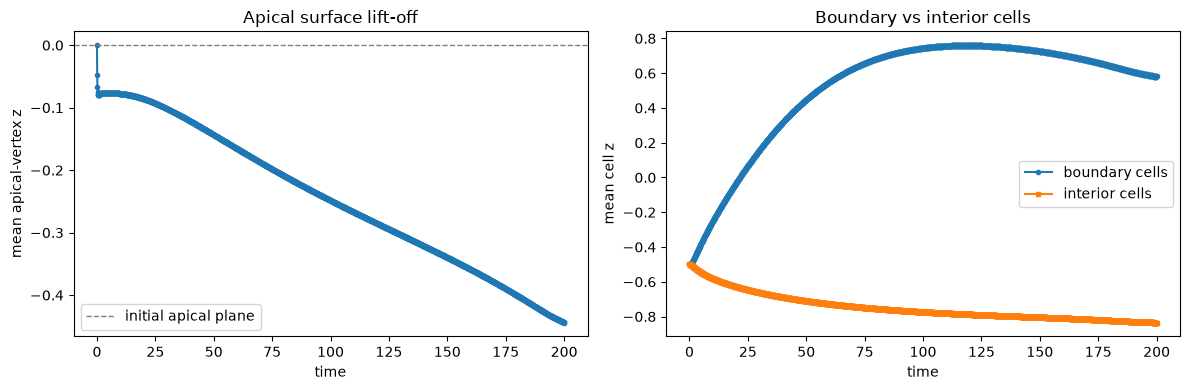

In [8]:
# Cells touching the apical boundary (one endpoint of a boundary apical edge).
_bnd_edges = mono.edge_df[boundary_apical_mask]
boundary_cells = set(_bnd_edges["cell"].unique())

times, apical_z = [], []
bnd_cell_z, int_cell_z = [], []
for r in results:
    times.append(r["global_time"])
    v = pd.DataFrame(r["vert_df"])
    apical_z.append(v.loc[v["segment"] == "apical", "z"].mean())
    c = pd.DataFrame(r["cell_df"])
    is_bnd = c.index.isin(boundary_cells)
    bnd_cell_z.append(c.loc[is_bnd, "z"].mean())
    int_cell_z.append(c.loc[~is_bnd, "z"].mean())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(times, apical_z, "-o", ms=3)
ax1.axhline(0.0, color="grey", ls="--", lw=1, label="initial apical plane")
ax1.set(xlabel="time", ylabel="mean apical-vertex z", title="Apical surface lift-off")
ax1.legend()

ax2.plot(times, bnd_cell_z, "-o", ms=3, label="boundary cells")
ax2.plot(times, int_cell_z, "-s", ms=3, label="interior cells")
ax2.set(xlabel="time", ylabel="mean cell z", title="Boundary vs interior cells")
ax2.legend()
plt.tight_layout(); plt.show()

### Final 3D shape

Scatter of the final vertex positions, colored by segment. Compare the apical
(top) layer's curvature against the flat starting plane.

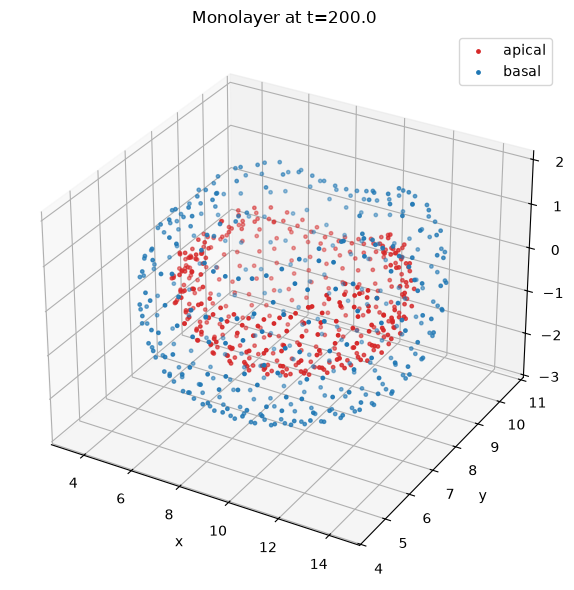

In [9]:
final_v = pd.DataFrame(results[-1]["vert_df"])
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
for seg, col in [("apical", "tab:red"), ("basal", "tab:blue")]:
    sv = final_v[final_v["segment"] == seg]
    ax.scatter(sv["x"], sv["y"], sv["z"], s=6, color=col, label=seg)
ax.set(xlabel="x", ylabel="y", zlabel="z", title=f"Monolayer at t={TF}")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Browse the history interactively

`EulerSolver` records the full epithelium at every step on its `History` object.
`tyssue.draw.browse_history` renders that with **ipyvolume** (the `viz3d` extra)
and an `ipywidgets` time slider, so you can scrub through the 3D monolayer frame
by frame and watch the apical rim peel off the z = 0 plane.

In [17]:
import ipyvolume as ipv
from tyssue.draw import browse_history
from tyssue import config as tyssue_config

# Pull the recorded History off the running solver instance and sync its datasets.
history = sim.state["Tyssue"]["instance"].history
history.update_datasets()

draw_specs = tyssue_config.draw.sheet_spec()
draw_specs["face"]["visible"] = True
draw_specs["face"]["color"] = "#bcd2ee"
draw_specs["face"]["alpha"] = 1.0
draw_specs["edge"]["color"] = "#333333"

# Work around the ipyvolume 0.6.3 + JupyterLab 4 "solid colour block" bug:
#  * an explicit figure size forces a real first paint (instead of the clear colour);
#  * an angled camera keeps the thin, flat slab from being viewed edge-on (which
#    otherwise fills the whole canvas with one colour and looks like a solid block).
# If it still shows solid, click-drag once on the canvas or resize the output area.
ipv.clear()
container = browse_history(history, coords=["x", "y", "z"],   **draw_specs)
ipv.view(azimuth=40, elevation=-65, distance=2.5)
ipv.pylab.style.box_on()
container

Container(figure=Figure(box_center=[0.5, 0.5, 0.5], box_size=[1.0, 1.0, 1.0], camera=PerspectiveCamera(fov=45.…

interactive(children=(IntSlider(value=0, description='i', max=1999), Output()), _dom_classes=('widget-interact…

### Matplotlib fallback browser (no WebGL)

If the ipyvolume canvas still misbehaves, this slider drives tyssue's **matplotlib**
3D drawer (`sheet_view_3d`, the backend `sheet_view(mode="3D")` dispatches to). It
never hits the WebGL solid-block bug, so it's the reliable way to scrub the history
while tweaking the model.

In [11]:
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
from tyssue.draw.plt_draw import sheet_view_3d

frame_times = history.slice()   # recorded time stamps

mpl_specs = tyssue_config.draw.sheet_spec()
mpl_specs["face"]["visible"] = True
mpl_specs["face"]["color"]   = "#bcd2ee"
mpl_specs["face"]["alpha"]   = 0.5
mpl_specs["edge"]["visible"] = True
mpl_specs["edge"]["color"]   = "#333333"
mpl_specs["vert"]["visible"] = False

def show_frame(i=0):
    t = frame_times[i]
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")   # matplotlib 3D: z axis points up
    sheet_view_3d(history.retrieve(t), coords=["x", "y", "z"],
                  ax=ax, view_angle=(25, -60), draw_order=("edge", "vert", "face"), **mpl_specs)
    ax.set(xlabel="x", ylabel="y", zlabel="z", title=f"t = {t:.2f}")
    plt.show()

interact(show_frame,
         i=IntSlider(value=0, min=0, max=len(frame_times) - 1, step=1, description="frame"))


interactive(children=(IntSlider(value=0, description='frame', max=1999), Output()), _dom_classes=('widget-inte…

<function __main__.show_frame(i=0)>

## 8. Static 3D snapshots: beginning, midpoint, final

Three matplotlib 3D views (via `sheet_view`'s 3D mode) at the start, middle and end
of the run. The x and y axes lie flat and **z points up**, so any upward bowing of
the apical surface off the original z = 0 plane is directly visible.

ValueError: Axis limits cannot be NaN or Inf

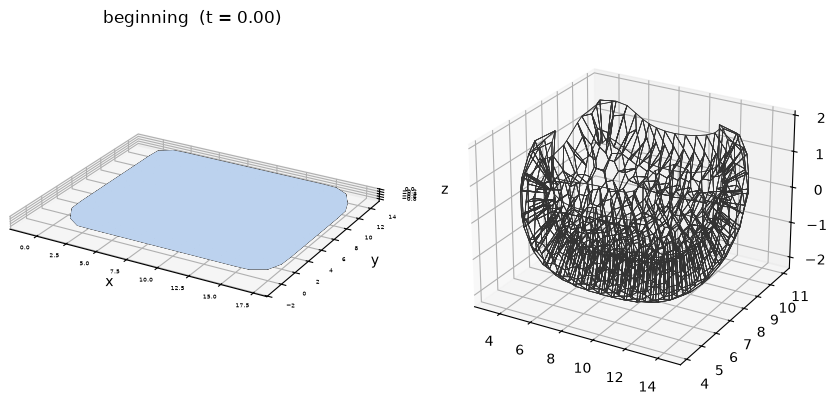

In [12]:
from tyssue.draw.plt_draw import sheet_view_3d

frame_times = history.slice()
snapshots = {
    "beginning": frame_times[0],
    "midpoint":  frame_times[len(frame_times) // 2],
    "final":     frame_times[-1],
}

panel_specs = tyssue_config.draw.sheet_spec()
panel_specs["cell"] = {}
panel_specs["cell"]["visible"] = True
panel_specs["cell"]["color"] = "#bcd2ee"
panel_specs["cell"]["alpha"] = 1.0
panel_specs["face"]["visible"] = True
panel_specs["face"]["color"]   = "#bcd2ee"
panel_specs["face"]["alpha"]   = 1.0
panel_specs["edge"]["visible"] = True
panel_specs["edge"]["color"]   = "#333333"
panel_specs["edge"]["alpha"] = 1.0
panel_specs["vert"]["visible"] = False

fig = plt.figure(figsize=(16, 5))
for i, (label, t) in enumerate(snapshots.items()):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")   # z axis up, x-y flat
    sheet_view_3d(history.retrieve(t), coords=["x", "y", "z"],
                  ax=ax, view_angle=(25, -60), draw_order=("edge", "vert", "face"), **panel_specs)
    ax.set(xlabel="x", ylabel="y", zlabel="z", title=f"{label}  (t = {t:.2f})")

plt.tight_layout()
plt.show()


---
**Where to go next**
- Sweep `BOUNDARY_APICAL_TENSION` (e.g. 0.1 → 2.0) and watch the apical-z curve in §6.
- Set `auto_reconnect=True` to allow T1 transitions during strong contraction.
- Add an external process (see `vivarium_tyssue/processes/regulations.py`) on the
  `Behaviors` port to make the tension dynamic.
- For a faithful animation install the `viz3d` extra (`ipyvolume`) and use
  `tyssue.draw.create_gif_3d` on `sim.state["Tyssue"]["instance"].history`.